# Описание проекта

**Задача**

Построить регрессионную модель прогноза ежедневных продаж (Sales) для каждой пары (магазин, дата).

**Данные**

Будем использовать датасет Rossmann Store Sales.

- Источник данных: репозиторий [`juniorcl/rossman-store-sales`](https://github.com/juniorcl/rossman-store-sales), исходные CSV лежат в папке `databases`.
- Локальный путь в проекте: `data/raw/rossmann`.
- Бизнес-смысл: прогноз ежедневных продаж для 1,115 магазинов Rossmann в Германии на горизонте до 6 недель.
- Тип задачи: **supervised time series / regression task**, так как для исторических дат известен целевой числовой отклик, а модель должна предсказывать будущие значения по календарным, промо- и магазинным признакам.
- Целевая переменная: **`Sales`** — дневная выручка магазина.

Файлы датасета:

- `train.csv` — обучающая таблица с историческими наблюдениями по парам магазин-дата. Содержит таргет `Sales`, количество клиентов `Customers`, календарные признаки и промо-признаки.
- `test.csv` — тестовая таблица для будущих дат. По структуре похожа на `train`, но не содержит `Sales` и `Customers`, потому что эти значения нужно прогнозировать/они неизвестны на момент прогноза.
- `store.csv` — справочник магазинов. Содержит статические свойства магазина, параметры конкуренции, тип ассортимента и признаки долгосрочной промо-кампании `Promo2`.

Поля `train.csv`:

- `Store` — идентификатор магазина.
- `DayOfWeek` — день недели.
- `Date` — календарная дата наблюдения.
- `Sales` — продажи за день; это таргет модели.
- `Customers` — количество клиентов за день; важный исторический индикатор спроса, но в реальном прогнозе может быть недоступен заранее.
- `Open` — был ли магазин открыт: `1` — открыт, `0` — закрыт.
- `Promo` — проводилась ли обычная промо-акция в этот день.
- `StateHoliday` — государственный праздник: `a` — public holiday, `b` — Easter holiday, `c` — Christmas, `0` — нет праздника.
- `SchoolHoliday` — попадала ли дата на школьные каникулы.

Поля `store.csv`:

- `Store` — идентификатор магазина для связи с `train` и `test`.
- `StoreType` — тип магазина: `a`, `b`, `c`, `d`.
- `Assortment` — уровень ассортимента: `a` — basic, `b` — extra, `c` — extended.
- `CompetitionDistance` — расстояние до ближайшего конкурента в метрах.
- `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear` — месяц и год открытия ближайшего конкурента.
- `Promo2` — участвует ли магазин в длительной повторяющейся промо-кампании.
- `Promo2SinceWeek` и `Promo2SinceYear` — неделя и год начала участия в `Promo2`.
- `PromoInterval` — месяцы, в которые повторяется кампания `Promo2`, например `Feb,May,Aug,Nov`.

**План**

- чтение данных
- препроцессинг
- анализ подготовленных данных
- baseline
- анализ результатов

# Импорт библиотек

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

In [ ]:
from app.forecasting.data.reader import DataReader
from app.forecasting.data.spliter import TemporalSpliter
from app.forecasting.preprocessing.module import PreprocessingModule
from app.forecasting.metrics.metrics import evaluate_model

# Загрузка сырых данных

In [3]:
reader = DataReader()
raw_data = reader.read()
train_raw = raw_data["train"]
test_raw = raw_data["test"]
store_raw = raw_data["store"]

reader.get_dataset_sizes()

{'train': (1017209, 9), 'test': (41088, 8), 'store': (1115, 10)}

# Разбиение данных

In [4]:
spliter = TemporalSpliter(train_ratio=0.8, val_ratio=0.2)

split = spliter.split(train_raw)
train_raw = split.train
val_raw = split.val
print("train size: ", train_raw.shape)
print("val size: ", val_raw.shape)


train size:  (806474, 9)
val size:  (210735, 9)


# Препроцессинг

Учитывая проведенный EDA сырых данных, препроцессинг выполнен по плану:

**Препроцессинг (`PreprocessingModule`)**

1. **Загрузить исходные данные**
   - через `DataReader` загрузить `train.csv`, `test.csv` и `store.csv` из `data/raw/rossmann`;
   - для препроцессинга использовать `train` и `store`; `test` — для инференса;
   - проверить размеры таблиц и согласованность `Store` между `train` и `store`.

2. **Объединить данные**
   - объединить транзакции и справочник магазинов по ключу `Store`;
   - использовать `left join`, чтобы сохранить все строки из `train` / `test`.

3. **Привести дату к правильному типу**
   - преобразовать колонку `Date` в `datetime`;
   - отсортировать данные по `Store` и `Date`.

4. **Обработать закрытые магазины**
   - оставить только строки с `Open == 1`;
   - закрытые дни (`Open == 0`) из обучающей выборки удаляются;
   - модель в baseline обучается только на открытых днях;
   - отдельное правило «если магазин закрыт → `Sales = 0`» в текущем пайплайне **не реализовано**.

5. **Обработать пропуски**
   - для `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear` добавить флаг `Competition_is_missing`, даты конкурента не заполнять медианами;
   - `competition_duration_months` считать только при известной дате открытия конкурента, иначе ставить `0`;
   - пропуски в `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval` при `Promo2 == 0` явно обнулять (`NA`);
   - пропуски в `CompetitionDistance` заполнять медианой, посчитанной на train;
   - пропуски в календарной сетке не синтезировать: добавить `days_since_prev_observation` и `is_first_observation`;
   - для недоступных лагов и rolling-значений добавить флаги `*_is_missing` и заполнить медианой продаж магазина (fallback — глобальная медиана).

6. **Сгенерировать календарные признаки**
   - `year`, `month`, `week`, `day`, `dayofweek`, `is_weekend`;
   - дополнительно: `is_month_start`, `is_month_end`, `quarter`, `season`;
   - исходный `DayOfWeek` из CSV в признаки не входит.

7. **Сгенерировать лаговые признаки по каждому магазину**
   - `lag_7`, `lag_14`, `lag_28` (без `lag_1`);
   - лаг = продажи того же магазина ровно `N` календарных дней назад;
   - при `transform` история для лагов строится из `sales_history_`, сохранённой на `fit` (для val/test подмешивается train);
   - если наблюдения на `Date - N days` нет, лаг остаётся пропуском до импутации.

8. **Сгенерировать rolling-признаки по каждому магазину**
   - `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28`;
   - `rolling_std_7`, `rolling_std_14`, `rolling_std_28`;
   - считать только по прошлым значениям (`shift(1)`), без текущего дня;
   - `min_periods = window // 2`;
   - недоступные значения импутировать медианой продаж / std магазина с флагами `*_is_missing`.

9. **Добавить признаки промо, праздников и магазина**
   - использовать `Promo`, `Promo2`, `PromoInterval`;
   - добавить `promo2_duration_weeks`, `is_current_month_in_promo_interval`, `is_state_holiday`;
   - использовать `StateHoliday`, `SchoolHoliday`;
   - закодировать `StoreType`, `Assortment`, `StateHoliday` через one-hot;
   - использовать `CompetitionDistance` и `competition_duration_months`;
   - `Customers` в признаки не включать.

10. **Выделить таргет**
    - основной таргет: `Sales`;
    - в baseline использовать `y = log1p(Sales)` (`use_log=True`);
    - для метрик и финального прогноза возвращать значения в исходную шкалу через `expm1`;
    - отрицательные предсказания после `expm1` обрезать до `0`.

11. **Финальная логика препроцессинга**
    - `fit` обучается только на train-сплите; статистики импутации и `sales_history_` сохраняются внутри модуля;
    - `transform` применяется к train, val и test с теми же правилами;
    - одна модель на все магазины; `Store` как id, различие рядов — через store-признаки, лаги и rolling;
    - прогноз строится для пары (магазин, дата) по календарным, промо, store-level, lag и rolling-признакам.

In [5]:
preprocessor = PreprocessingModule(use_log=True)

preprocessor.fit(train_raw, store_raw)
train_df = preprocessor.transform(train_raw)
val_df = preprocessor.transform(val_raw)

In [6]:
print("Train dates:", train_df["Date"].min(), "->", train_df["Date"].max())
print("Val dates:  ", val_df["Date"].min(), "->", val_df["Date"].max())

train_dates = set(train_df["Date"].unique())
val_dates = set(val_df["Date"].unique())
overlap = train_dates & val_dates
print(f"Пересекающихся дат: {len(overlap)}")

Train dates: 2013-01-01 00:00:00 -> 2015-01-23 00:00:00
Val dates:   2015-01-24 00:00:00 -> 2015-07-31 00:00:00
Пересекающихся дат: 0


In [7]:
features = preprocessor.feature_columns_

X_train = train_df[features]
y_train = train_df["y"]

X_val = val_df[features]
y_val = val_df["y"]

print("Prepared train size: ", X_train.shape)
print("Prepared val size: ", X_val.shape)
print("Target train size: ", y_train.shape)
print("Target val size: ", y_val.shape)


Prepared train size:  (669308, 49)
Prepared val size:  (175084, 49)
Target train size:  (669308,)
Target val size:  (175084,)


# Анализ данных

## Базовая структура после препроцессинга

In [8]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("\nNaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_val:", X_val.isna().sum().sum())
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_val:", y_val.isna().sum())

print("\nDuplicate columns:", X_train.columns[X_train.columns.duplicated()].tolist())

X_train: (669308, 49)
X_val: (175084, 49)
y_train: (669308,)
y_val: (175084,)

NaN in X_train: 0
NaN in X_val: 0
NaN in y_train: 0
NaN in y_val: 0

Duplicate columns: []


Размеры train/validation согласованы, пропусков после препроцессинга нет, данные готовы к обучению.

## Распределение таргета в train и validation

In [9]:
target_report = pd.DataFrame(
    {
        "train": y_train.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
        "val": y_val.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
    }
)

display(target_report)

print("Train skew:", y_train.skew())
print("Val skew:", y_val.skew())

,train,val
count,669308.000000,175084.000000
mean,8.749296,8.787303
std,0.435046,0.413371
min,0.000000,0.000000
1%,7.679251,7.730175
5%,8.049746,8.117312
25%,8.478244,8.530307
50%,8.751316,8.788898
75%,9.025696,9.051462
95%,9.445571,9.451705


Train skew: -0.70703394061108
Val skew: -0.3115991474003466


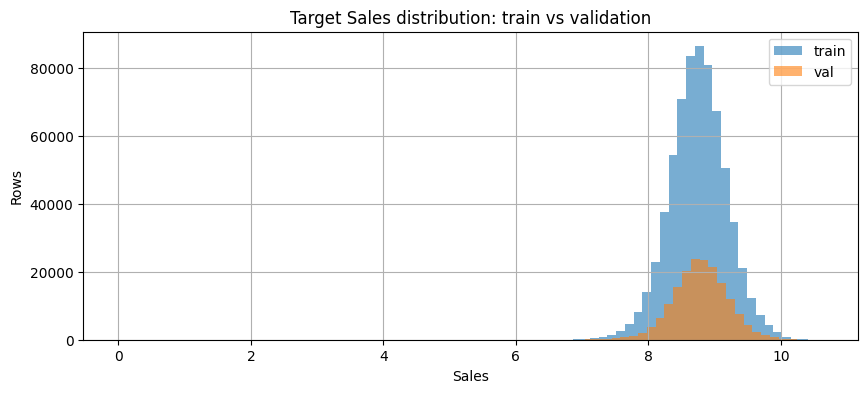

In [10]:
plt.figure(figsize=(10, 4))
y_train.hist(bins=80, alpha=0.6, label="train")
y_val.hist(bins=80, alpha=0.6, label="val")
plt.title("Target Sales distribution: train vs validation")
plt.xlabel("Sales")
plt.ylabel("Rows")
plt.legend()
plt.show()

- В препроцессинге делали log1p, чтобы сделать распределение более симметричным, потом не забыдь обратно приводить.
- min = 0 — это log1p(0), то есть дни с нулевыми продажами (магазин закрыт и т.п.). Они и тянут распределение влево.
- При этом среднее и медиана близки (8.75), значит основная масса данных почти симметрична. Сильного distribution shift между сплитами нет, val чуть менее асимметричен, но это объясняется бОльшим количеством данных.

## Доли бинарных признаков в train и validation

Проверим баланса бинарных признаков между train и validation.

- binary_cols — все колонки в X_train, у которых не больше 2 уникальных значений.
- train_share_1 / val_share_1 — доля единиц
- abs_diff — модуль разницы между train и val

In [11]:
binary_cols = [
    col for col in X_train.columns
    if X_train[col].nunique() <= 2
]

binary_balance = pd.DataFrame(
    {
        "train_share_1": X_train[binary_cols].mean(),
        "val_share_1": X_val[binary_cols].mean(),
    }
)

binary_balance["abs_diff"] = (
    binary_balance["train_share_1"] - binary_balance["val_share_1"]
).abs()

display(binary_balance.sort_values("abs_diff", ascending=False).head(30))

,train_share_1,val_share_1,abs_diff
SchoolHoliday,0.201687,0.162585,0.039103
lag_28_is_missing,0.075644,0.041968,0.033675
rolling_std_28_is_missing,0.023323,0.000000,0.023323
rolling_mean_28_is_missing,0.023323,0.000000,0.023323
lag_14_is_missing,0.057672,0.035868,0.021803
Promo,0.442636,0.460556,0.017920
Promo2,0.495685,0.510149,0.014464
is_current_month_in_promo_interval,0.163037,0.177269,0.014232
rolling_mean_14_is_missing,0.011661,0.000000,0.011661
rolling_std_14_is_missing,0.011661,0.000000,0.011661


Для baseline-модели validation выглядит репрезентативным, серьёзного distribution shift нет.

## Проверка числовых признаков на сдвиг между train и validation

Сравниваем mean / std / median в train и val. Для ранжирования используем **std_normalized_diff** (разница средних в единицах std train) и **rel_mean_diff_pct** (относительный сдвиг средних в процентах). Календарные колонки и флаги импутации вынесены отдельно.

In [12]:
numeric_cols = X_train.select_dtypes(include=["int64", "int32", "float64", "bool"]).columns

drift_report = pd.DataFrame(
    {
        "train_mean": X_train[numeric_cols].mean(),
        "val_mean": X_val[numeric_cols].mean(),
        "train_std": X_train[numeric_cols].std(),
        "val_std": X_val[numeric_cols].std(),
        "train_median": X_train[numeric_cols].median(),
        "val_median": X_val[numeric_cols].median(),
    }
)

eps = 1e-6
drift_report["mean_abs_diff"] = (
    drift_report["train_mean"] - drift_report["val_mean"]
).abs()
drift_report["rel_mean_diff_pct"] = (
    drift_report["mean_abs_diff"] / drift_report["train_mean"].abs().clip(lower=eps) * 100
)
drift_report["std_normalized_diff"] = (
    drift_report["mean_abs_diff"] / drift_report["train_std"].clip(lower=eps)
)

CALENDAR_COLS = {"year", "month", "week", "day", "quarter", "season"}


def _feature_group(col: str) -> str:
    if col in CALENDAR_COLS:
        return "calendar"
    if col.startswith(("lag_", "rolling_")):
        return "history"
    if col.startswith(("StoreType_", "Assortment_", "StateHoliday_")) or col in {
        "CompetitionDistance",
        "Competition_is_missing",
        "competition_duration_months",
    }:
        return "static"
    if "promo" in col.lower() or col in {
        "Promo",
        "Promo2",
        "is_current_month_in_promo_interval",
    }:
        return "promo"
    if col.endswith("_is_missing"):
        return "imputation_flag"
    return "other"


drift_report["group"] = drift_report.index.map(_feature_group)

drift_candidates = drift_report[~drift_report["group"].isin({"calendar", "imputation_flag"})]

display_cols = [
    "group",
    "train_mean",
    "val_mean",
    "train_median",
    "val_median",
    "rel_mean_diff_pct",
    "std_normalized_diff",
]

print("Топ сдвигов (std_normalized_diff, без календаря и флагов импутации):")
display(
    drift_candidates.sort_values("std_normalized_diff", ascending=False)
    .head(20)[display_cols]
)

print("\nКалендарные признаки (ожидаемый сдвиг из-за разных временных окон):")
display(
    drift_report.loc[drift_report["group"] == "calendar", ["train_mean", "val_mean", "train_std", "val_std"]]
)

Топ сдвигов (std_normalized_diff, без календаря и флагов импутации):


,group,train_mean,val_mean,train_median,val_median,rel_mean_diff_pct,std_normalized_diff
promo2_duration_weeks,promo,49.853047,82.945849,0.000000,17.000000,66.380701,0.439867
competition_duration_months,static,39.881636,49.874015,13.000000,29.000000,25.055088,0.156830
rolling_std_28_is_missing,history,0.023323,0.000000,0.000000,0.000000,100.000000,0.154530
rolling_mean_28_is_missing,history,0.023323,0.000000,0.000000,0.000000,100.000000,0.154530
lag_28_is_missing,history,0.075644,0.041968,0.000000,0.000000,44.518352,0.127352
is_first_observation,other,0.001666,0.006368,0.000000,0.000000,282.278221,0.115309
rolling_mean_14_is_missing,history,0.011661,0.000000,0.000000,0.000000,100.000000,0.108623
rolling_std_14_is_missing,history,0.011661,0.000000,0.000000,0.000000,100.000000,0.108623
SchoolHoliday,other,0.201687,0.162585,0.000000,0.000000,19.387723,0.097449
lag_14_is_missing,history,0.057672,0.035868,0.000000,0.000000,37.805512,0.093526



Календарные признаки (ожидаемый сдвиг из-за разных временных окон):


,train_mean,val_mean,train_std,val_std
year,2013.526384,2015.000000,0.558480,0.000000
month,6.228115,4.383993,3.514137,1.838711
week,25.171341,17.818818,15.286473,7.905093
day,15.684585,16.413299,8.646434,8.799692
quarter,2.423437,1.808812,1.127846,0.706738
season,2.441671,2.137243,1.122872,0.716550


Вывод:

- Лаги и rolling сдвинуты слабо (2–3%). 
- Заметно отличаются promo2_duration_weeks и competition_duration_months (программы нарастают со временем). 
- Высокие *_is_missing — артефакт препроцессинга, не реальный shift. 
- Календарные признаки различаются ожидаемо из‑за разных временных окон.

## Проверка lag/rolling

Есть признаки по типу lag_7_is_missing, rolling_mean_7_is_missing, которые образовались в результате заполнения медианными значениями Nan при lag и rolling. 

In [13]:
missing_flag_cols = [
    col for col in X_train.columns
    if col.endswith("_is_missing") or "is_missing" in col
]

missing_flags_report = pd.DataFrame(
    {
        "train_share": X_train[missing_flag_cols].mean(),
        "val_share": X_val[missing_flag_cols].mean(),
    }
)

missing_flags_report["abs_diff"] = (
    missing_flags_report["train_share"] - missing_flags_report["val_share"]
).abs()

display(missing_flags_report.sort_values("abs_diff", ascending=False))

,train_share,val_share,abs_diff
lag_28_is_missing,0.075644,0.041968,0.033675
rolling_mean_28_is_missing,0.023323,0.000000,0.023323
rolling_std_28_is_missing,0.023323,0.000000,0.023323
lag_14_is_missing,0.057672,0.035868,0.021803
rolling_mean_14_is_missing,0.011661,0.000000,0.011661
rolling_std_14_is_missing,0.011661,0.000000,0.011661
lag_7_is_missing,0.042807,0.035611,0.007195
rolling_mean_7_is_missing,0.004998,0.000000,0.004998
rolling_std_7_is_missing,0.004998,0.000000,0.004998
Competition_is_missing,0.318248,0.317636,0.000612


Видим, что в validation доля немного ниже. Незначительные отличия.

In [14]:
lag_rolling_cols = [
    "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_14", "rolling_std_28"
]

lag_rolling_report = pd.DataFrame(
    {
        "train_mean": X_train[lag_rolling_cols].mean(),
        "val_mean": X_val[lag_rolling_cols].mean(),
        "train_median": X_train[lag_rolling_cols].median(),
        "val_median": X_val[lag_rolling_cols].median(),
        "train_min": X_train[lag_rolling_cols].min(),
        "val_min": X_val[lag_rolling_cols].min(),
        "train_max": X_train[lag_rolling_cols].max(),
        "val_max": X_val[lag_rolling_cols].max(),
    }
)

display(lag_rolling_report)

,train_mean,val_mean,train_median,val_median,train_min,val_min,train_max,val_max
lag_7,6878.428781,6986.873901,6304.000000,6429.000000,0.000000,0.000000,38025.000000,41551.000000
lag_14,6898.030570,7048.283207,6319.000000,6491.000000,0.000000,0.000000,38025.000000,38722.000000
lag_28,6882.806805,7059.880869,6301.000000,6504.000000,0.000000,0.000000,38037.000000,41551.000000
rolling_mean_7,6918.032323,7057.800875,6453.142857,6617.000000,467.333333,1511.000000,31570.857143,29380.428571
rolling_mean_14,6918.963757,7064.079102,6496.500000,6661.642857,1263.857143,2201.071429,27359.071429,25324.642857
rolling_mean_28,6908.667458,7077.621001,6507.589286,6693.803571,1403.090909,2339.928571,26101.785714,24004.964286
rolling_std_7,1560.145245,1519.587572,1389.213969,1363.985363,10.785793,101.557396,14437.039239,13341.477454
rolling_std_14,1708.976318,1658.123879,1566.677440,1534.529629,123.590004,300.208096,10873.430118,10447.529082
rolling_std_28,1744.534912,1697.214824,1613.882521,1586.604823,188.735821,327.322186,8532.232070,7850.951455


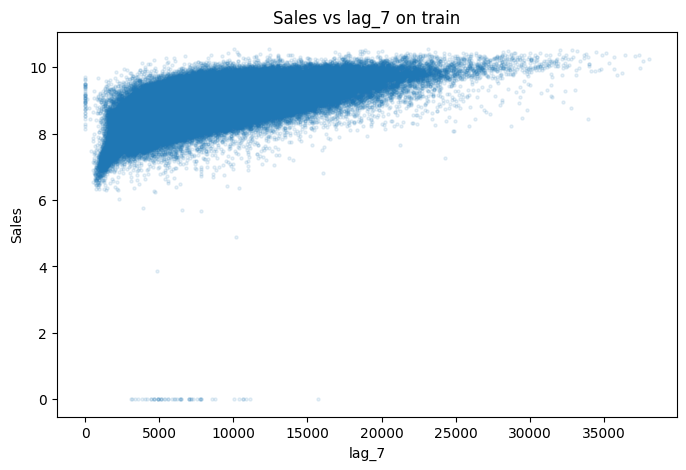

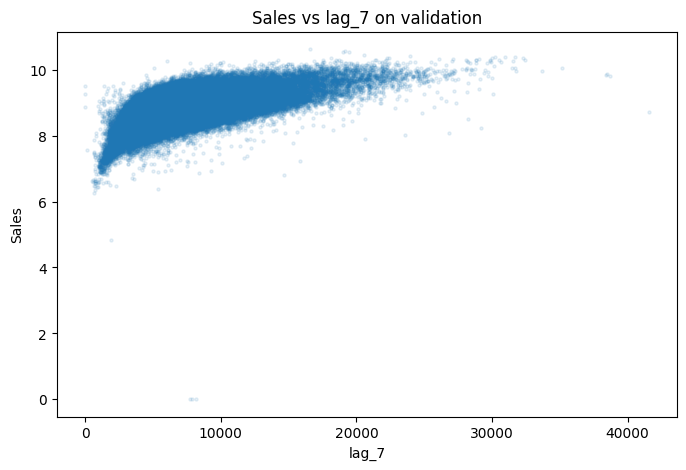

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train["lag_7"], y_train, alpha=0.1, s=5)
plt.title("Sales vs lag_7 on train")
plt.xlabel("lag_7")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_val["lag_7"], y_val, alpha=0.1, s=5)
plt.title("Sales vs lag_7 on validation")
plt.xlabel("lag_7")
plt.ylabel("Sales")
plt.show()

Видим, что:

- У validation статистики немного выше, чем у train, то есть продаж стало больше;
- Для train и validation видна явная положительная связь (чем выше продажи неделю назад, тем выше текущие продажи) - все верно;
- Паттерн на train и validation похожий, значит lag_7 - стабильный признак.
- На графиках есть точки с низкими продажами при ненулевых лагах. Это ожидаемо для аномальных дней, закрытий, праздников...

Проверим мультиколлинеарность среди lag/rolling

In [16]:
corr_lag_roll = X_train[lag_rolling_cols].corr()

display(corr_lag_roll)

,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_14,rolling_std_28
lag_7,1.000000,0.638548,0.663576,0.846226,0.807731,0.802315,0.450564,0.527599,0.532195
lag_14,0.638548,1.000000,0.821469,0.706866,0.821804,0.807848,0.419359,0.558367,0.566271
lag_28,0.663576,0.821469,1.000000,0.706494,0.772784,0.807673,0.394410,0.507553,0.589097
rolling_mean_7,0.846226,0.706866,0.706494,1.000000,0.959323,0.945282,0.594190,0.634577,0.636935
rolling_mean_14,0.807731,0.821804,0.772784,0.959323,1.000000,0.984451,0.558009,0.672260,0.677221
rolling_mean_28,0.802315,0.807848,0.807673,0.945282,0.984451,1.000000,0.537715,0.650925,0.703072
rolling_std_7,0.450564,0.419359,0.394410,0.594190,0.558009,0.537715,1.000000,0.827135,0.750090
rolling_std_14,0.527599,0.558367,0.507553,0.634577,0.672260,0.650925,0.827135,1.000000,0.905115
rolling_std_28,0.532195,0.566271,0.589097,0.636935,0.677221,0.703072,0.750090,0.905115,1.000000


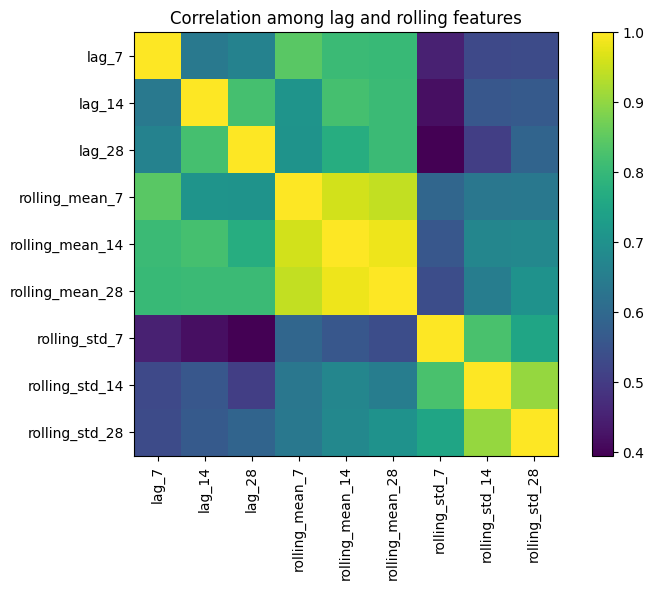

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_lag_roll)
plt.xticks(range(len(corr_lag_roll.columns)), corr_lag_roll.columns, rotation=90)
plt.yticks(range(len(corr_lag_roll.index)), corr_lag_roll.index)
plt.colorbar()
plt.title("Correlation among lag and rolling features")
plt.tight_layout()
plt.show()

- Матрица корреляций показывает, что lag- и rolling-признаки сильно связаны между собой. Особенно высоко коррелируют `rolling_mean_14` и `rolling_mean_28` — **0.98**, а также `rolling_mean_7` и `rolling_mean_14` — **0.96**.
- Это ожидаемо. Для бустинга это не критично, но для линейных моделей может потребоваться регуляризация или отбор признаков.

## Корреляция с target

In [18]:
corr_with_target = X_train.copy()
corr_with_target["Sales"] = y_train.values

target_corr = (
    corr_with_target
    .corr(numeric_only=True)["Sales"]
    .drop("Sales")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(target_corr.head(25))

lag_14                                0.770832
lag_28                                0.731486
rolling_mean_14                       0.726638
rolling_mean_28                       0.723762
rolling_mean_7                        0.682163
lag_7                                 0.596837
rolling_std_28                        0.482293
rolling_std_14                        0.477878
rolling_std_7                         0.399443
Promo                                 0.397273
is_weekend                           -0.197370
dayofweek                            -0.191061
Promo2                               -0.117741
Assortment_a                         -0.113341
StoreType_b                           0.106558
Assortment_c                          0.105777
week                                  0.088037
month                                 0.086319
quarter                               0.075786
day                                  -0.063055
is_current_month_in_promo_interval   -0.057083
is_month_end 

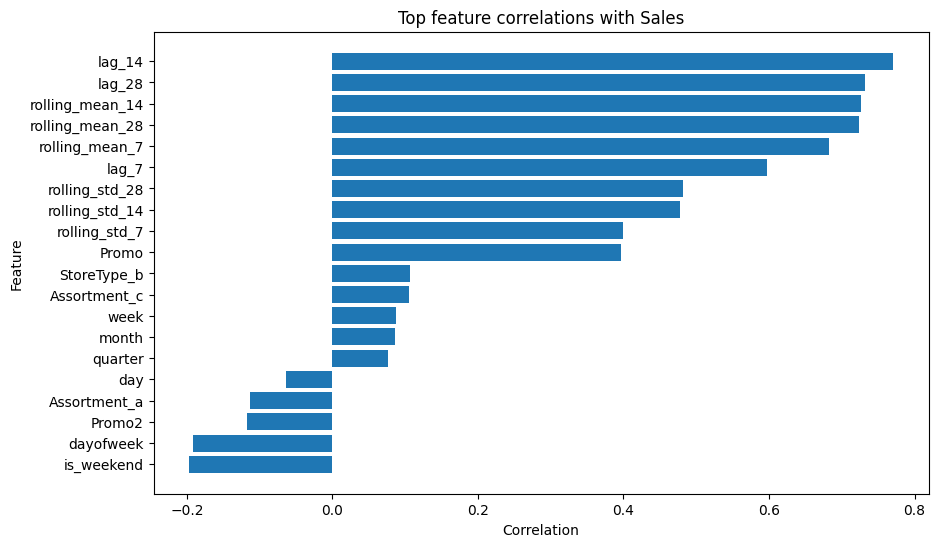

In [19]:
top_corr = target_corr.head(20).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index, top_corr.values)
plt.title("Top feature correlations with Sales")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

- Самые сильные связи с таргетом: `lag_14`, `lag_28`, `rolling_mean_14`, `rolling_mean_28`, `rolling_mean_7`. То есть, прошлые продажи являются основным источником сигнала.
- `Promo` также заметно связан с таргетом: корреляция около **0.40**, значит промоакции важны.
- `is_weekend` и `dayofweek` имеют отрицательную корреляцию с продажами, что логично: в данных часть выходных и воскресений связана с закрытием или снижением продаж.

## Проверка на constant признаки

In [20]:
constant_report = pd.DataFrame(
    {
        "n_unique_train": X_train.nunique(),
        "most_common_share_train": X_train.apply(lambda s: s.value_counts(normalize=True).iloc[0]),
        "n_unique_val": X_val.nunique(),
        "most_common_share_val": X_val.apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    }
)

display(
    constant_report
    .sort_values("most_common_share_train", ascending=False)
    .head(25)
)

,n_unique_train,most_common_share_train,n_unique_val,most_common_share_val
StateHoliday_c,2,0.999894,1,1.000000
StateHoliday_b,2,0.999857,2,0.999720
StateHoliday_a,2,0.999220,2,0.999018
is_state_holiday,2,0.998971,2,0.998738
is_first_observation,2,0.998334,2,0.993632
rolling_mean_7_is_missing,2,0.995002,1,1.000000
rolling_std_7_is_missing,2,0.995002,1,1.000000
Assortment_b,2,0.990272,2,0.990285
rolling_mean_14_is_missing,2,0.988339,1,1.000000
rolling_std_14_is_missing,2,0.988339,1,1.000000


- Проверка показывает, что праздничные признаки `StateHoliday_*` почти всегда равны 0. Они редкие, но могут быть полезны для отдельных дней.
- Missing-флаги для rolling-признаков в validation стали константными. Если признак в validation всегда принимает одно значение, он не помогает различать строки внутри validation, но может быть полезен в других временных фолдах или на test.
- `StoreType_b` и `Assortment_b` редкие, но ранее было видно, что они связаны с более высокими продажами. Поэтому их лучше оставить, несмотря на дисбаланс.

## Общий вывод по анализу:

- Сплит сделан корректно;
- Дублей нет;
- Распределения признаков train и test в целом схожи; 
- Наиболее важными признаками показались лаги, rolling-статистики, промо и календарные признаки;
- Явных признаков leakage не выявлено;

Можно приступать к baseline.

# Save prepared data

In [22]:
output_dir = PROJECT_ROOT / "data" / "prepared_data"
output_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(output_dir / "X_train.csv", index=False)
y_train.to_csv(output_dir / "y_train.csv", index=False)
X_val.to_csv(output_dir / "X_val.csv", index=False)
y_val.to_csv(output_dir / "y_val.csv", index=False)

# Baseline

Для первичного сравнения были выбраны две простые модели и одна усложнённая модель.

- **Dummy median** — наивный baseline, который всегда предсказывает медианное значение `log1p(Sales)` из train.
- **Naive lag_7** — forecasting baseline, который использует продажи магазина за аналогичный день неделю назад.
- **Ridge regression** — простая линейная модель, обученная на всех подготовленных признаках.
- **HistGradientBoostingRegressor** — усложнённая нелинейная модель с подбором гиперпараметров.

Так как таргет был преобразован через `log1p(Sales)`, модели обучались в логарифмической шкале. Для оценки качества предсказания переводились обратно в исходную шкалу продаж через `expm1`.

В качестве метрик использовались:

- **MAE** — средняя абсолютная ошибка в денежных единицах продаж;
- **RMSE** — ошибка, сильнее штрафующая крупные промахи;
- **RMSPE** — относительная ошибка, близкая к метрике исходной Rossmann-задачи;
- **R2** — доля объяснённой дисперсии.

$$
RMSPE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \frac{y_i - \hat{y}_i}{y_i} \right)^2}
$$

где:

- $y_i$ — истинное значение продаж;
- $\hat{y}_i$ — предсказанное значение продаж;
- $n$ — количество наблюдений.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

где:

- $y_i$ — истинное значение продаж;
- $\hat{y}_i$ — предсказанное значение продаж;
- $\bar{y}$ — среднее значение истинных продаж;
- $n$ — количество наблюдений.

Основной метрикой для выбора модели является **RMSPE**, так как она оценивает относительную ошибку прогноза и лучше подходит для магазинов разного масштаба. Дополнительно использовалась совокупная метрика `combined_score`, объединяющая `RMSPE`, нормированный `MAE` и нормированный `RMSE`.


$$
CombinedScore = \frac{RMSPE + MAE_{norm} + RMSE_{norm}}{3}
$$

где:

$$
MAE_{norm} = \frac{MAE}{\bar{y}}
$$

$$
RMSE_{norm} = \frac{RMSE}{\bar{y}}
$$

Итого:

$$
CombinedScore = \frac{1}{3}
\left(
RMSPE + \frac{MAE}{\bar{y}} + \frac{RMSE}{\bar{y}}
\right)
$$

где:

- $RMSPE$ — относительная ошибка прогноза;
- $MAE$ — средняя абсолютная ошибка;
- $RMSE$ — среднеквадратичная ошибка;
- $\bar{y}$ — среднее значение истинных продаж на validation;
- чем меньше `CombinedScore`, тем лучше модель.

In [21]:
results = []

## Naive

In [22]:
lag7_val_pred_sales = X_val["lag_7"].values
lag7_val_pred_sales = np.clip(lag7_val_pred_sales, 0, None)

lag7_val_pred = np.log1p(lag7_val_pred_sales)

results_lag7 = evaluate_model(
    "Naive lag_7",
        y_val,
        lag7_val_pred
    )
results.append(results_lag7)
results_lag7



{'model': 'Naive lag_7',
 'MAE': 2033.0308309154464,
 'RMSE': np.float64(2650.980794417709),
 'RMSPE': np.float64(0.38506356639100575),
 'R2': 0.24730252599226288}

## Dummy

In [23]:
dummy_model = DummyRegressor(strategy="median")

dummy_model.fit(X_train, y_train)

dummy_val_pred_log = dummy_model.predict(X_val)

results_dummy = evaluate_model(
        "Dummy median",
        y_val,
        dummy_val_pred_log
    )
results.append(results_dummy)
results_dummy

{'model': 'Dummy median',
 'MAE': 2224.460767403075,
 'RMSE': np.float64(3159.9767321832082),
 'RMSPE': np.float64(0.5098439121679382),
 'R2': -0.06948590518575992}

## Ridge

Ridge — это линейная модель с L2-регуляризацией. У меня признаки разных масштабов, поэтому здесь лучше добавить scaling.

In [24]:
ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_val_pred = ridge_model.predict(X_val)

results_ridge = evaluate_model(
    "Ridge regression",
    y_val,
    ridge_val_pred
)
results.append(results_ridge)
results_ridge

{'model': 'Ridge regression',
 'MAE': 1007.3138354271123,
 'RMSE': np.float64(1922.2415015324598),
 'RMSPE': np.float64(0.22039207223142487),
 'R2': 0.6042479303218884}

## HistGradientBoostingRegressor (HGBR)

В усложнённой модели `HistGradientBoostingRegressor` я подбираю гиперпараметры, которые отвечают за сложность модели, скорость обучения и регуляризацию:

- `learning_rate` — скорость обучения;
- `max_leaf_nodes` — максимальное количество листьев в одном дереве;
- `max_iter` — количество boosting-итераций, то есть количество деревьев;
- `l2_regularization` — L2-регуляризация;

Подбор выполняется по сетке параметров (`grid search`). Для каждой комбинации модель обучается на train и оценивается на validation. Основной критерий выбора лучшей комбинации — минимальное значение `RMSPE`.

In [25]:
param_grid = {
    "learning_rate": [0.03, 0.05, 0.08],
    "max_leaf_nodes": [31, 63],
    "max_iter": [300, 500],
    "l2_regularization": [0.0, 0.1],
}

best_model = None
best_params = None
best_score = np.inf
gb_results = []

for params in tqdm(ParameterGrid(param_grid)):
    model = HistGradientBoostingRegressor(
        loss="squared_error",
        random_state=42,
        **params
    )
    
    model.fit(X_train, y_train)
    
    val_pred = model.predict(X_val)
    
    metrics = evaluate_model(
        "HistGradientBoosting",
        y_val,
        val_pred
    )
    
    metrics.update(params)
    gb_results.append(metrics)
    
    # Основная метрика для выбора модели — RMSPE
    if metrics["RMSPE"] < best_score:
        best_score = metrics["RMSPE"]
        best_model = model
        best_params = params

gb_results = pd.DataFrame(gb_results).sort_values("RMSPE")

display(gb_results)

print("Best params:", best_params)
print("Best RMSPE:", best_score)

100%|██████████| 24/24 [06:28<00:00, 16.18s/it]


,model,MAE,RMSE,RMSPE,R2,l2_regularization,learning_rate,max_iter,max_leaf_nodes
23,HistGradientBoosting,651.989383,955.190885,0.140890,0.902279,0.1,0.08,500,63
21,HistGradientBoosting,651.989383,955.190885,0.140890,0.902279,0.1,0.08,300,63
15,HistGradientBoosting,645.822966,950.536418,0.141009,0.903229,0.1,0.03,500,63
3,HistGradientBoosting,651.813648,957.282414,0.141166,0.901851,0.0,0.03,500,63
19,HistGradientBoosting,652.476185,959.530214,0.141210,0.901389,0.1,0.05,500,63
6,HistGradientBoosting,651.000316,954.186019,0.141557,0.902485,0.0,0.05,500,31
17,HistGradientBoosting,653.911196,963.421764,0.141685,0.900588,0.1,0.05,300,63
8,HistGradientBoosting,660.702871,961.621432,0.141929,0.900959,0.0,0.08,300,31
9,HistGradientBoosting,659.403742,963.838405,0.141941,0.900502,0.0,0.08,300,63
1,HistGradientBoosting,648.781327,958.040915,0.142006,0.901695,0.0,0.03,300,63


Best params: {'l2_regularization': 0.1, 'learning_rate': 0.08, 'max_iter': 300, 'max_leaf_nodes': 63}
Best RMSPE: 0.14089043763759293


In [26]:
best_gb_val_pred = best_model.predict(X_val)

results_hgb = evaluate_model(   
    "HistGradientBoosting tuned",
    y_val,
    best_gb_val_pred
)
results.append(results_hgb)
results_hgb

{'model': 'HistGradientBoosting tuned',
 'MAE': 651.9893829716856,
 'RMSE': np.float64(955.1908845158707),
 'RMSPE': np.float64(0.14089043763759293),
 'R2': 0.9022790603506152}

## Сравнение результатов

In [27]:
results_df = pd.DataFrame(results)

val_mean_sales = y_val.mean()

results_df["MAE_norm"] = results_df["MAE"] / val_mean_sales
results_df["RMSE_norm"] = results_df["RMSE"] / val_mean_sales

results_df["combined_score"] = (
    results_df["RMSPE"]
    + results_df["MAE_norm"]
    + results_df["RMSE_norm"]
) / 3

results_df = results_df.sort_values("combined_score")

display(results_df)

,model,MAE,RMSE,RMSPE,R2,MAE_norm,RMSE_norm,combined_score
3,HistGradientBoosting tuned,651.989383,955.190885,0.140890,0.902279,74.196757,108.701258,61.012968
2,Ridge regression,1007.313835,1922.241502,0.220392,0.604248,114.632879,218.752160,111.201810
0,Naive lag_7,2033.030831,2650.980794,0.385064,0.247303,231.360047,301.683100,177.809404
1,Dummy median,2224.460767,3159.976732,0.509844,-0.069486,253.144882,359.607122,204.420616


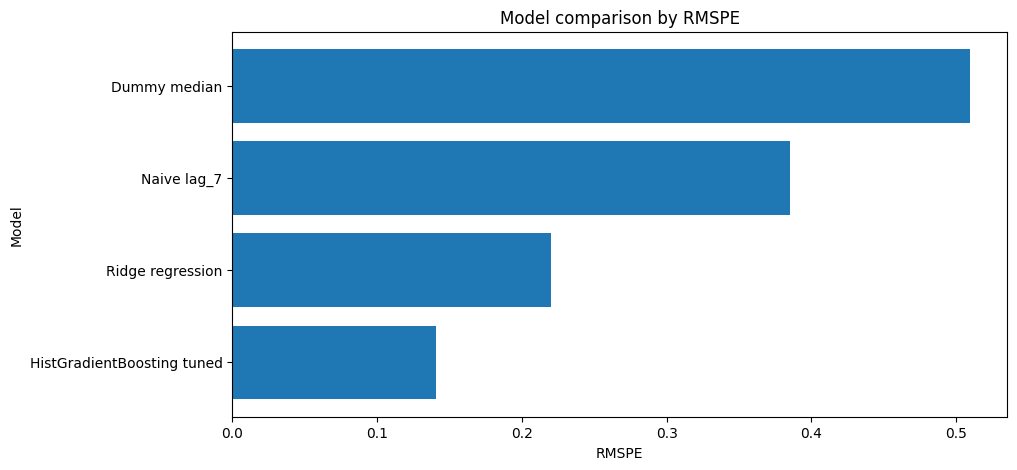

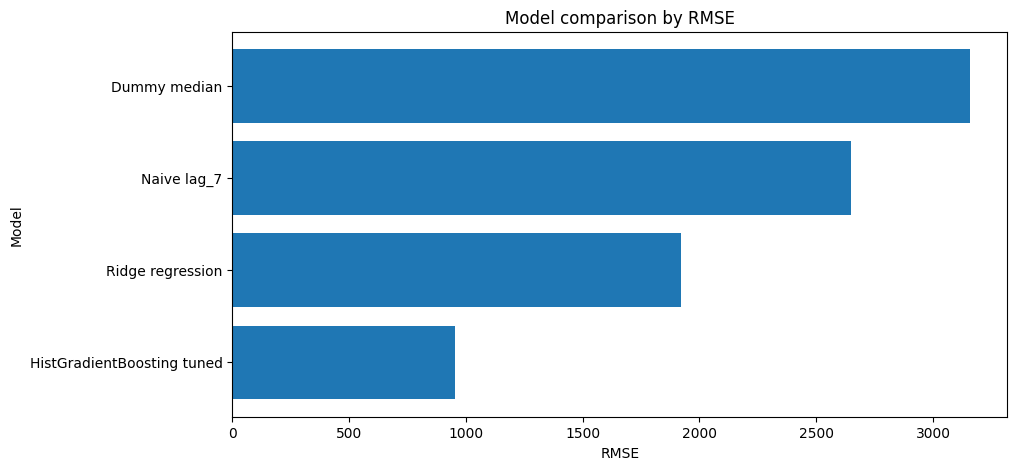

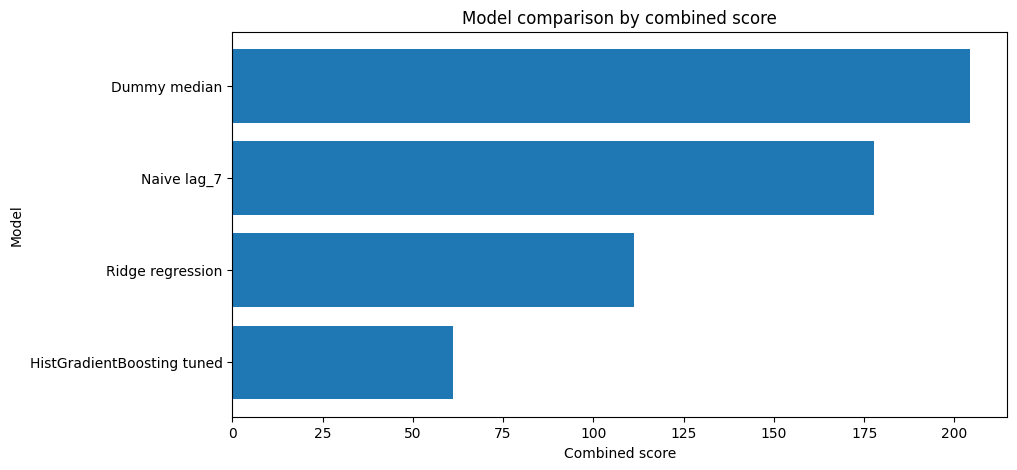

In [28]:
plot_df = results_df.sort_values("RMSPE")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"], plot_df["RMSPE"])
plt.title("Model comparison by RMSPE")
plt.xlabel("RMSPE")
plt.ylabel("Model")
plt.show()

plot_df = results_df.sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"], plot_df["RMSE"])
plt.title("Model comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

plot_df = results_df.sort_values("combined_score")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"], plot_df["combined_score"])
plt.title("Model comparison by combined score")
plt.xlabel("Combined score")
plt.ylabel("Model")
plt.show()

**Вывод**

- Лучший результат показывает `HistGradientBoosting tuned`: `MAE = 652`, `RMSE = 955`, `RMSPE = 0.141`, `R2 = 0.902`.
- Модель существенно превосходит простые baseline-подходы: по сравнению с `Naive lag_7` ошибка `RMSPE` снизилась с **0.385** до **0.141**.
- `Ridge regression` работает лучше наивных моделей, но заметно хуже бустинга: `R2 = 0.604` против `0.902`.
- `Dummy median` показывает худшее качество и имеет отрицательный `R2`, значит простое предсказание медианы хуже, чем полноценная модель с признаками.
- Основной вывод: нелинейная модель лучше использует лаги, rolling-признаки, промо, календарные признаки и признаки магазина.

,y_true,y_pred,abs_error,pct_error
count,175084.000000,175084.000000,175084.000000,1.750810e+05
mean,7123.461361,6871.055589,651.989383,9.200240e-02
std,3055.607676,2821.786496,698.070379,1.067040e-01
min,0.000000,41.292894,0.004514,7.519593e-07
50%,6560.000000,6351.367729,461.430708,7.313522e-02
75%,8530.000000,8180.690077,861.309756,1.255913e-01
90%,10894.000000,10327.018919,1422.874027,1.861711e-01
95%,12728.850000,11953.895670,1892.830406,2.324936e-01
99%,17640.000000,16821.479819,3221.967106,3.480721e-01
max,41551.000000,28131.883375,32008.152362,1.574514e+01


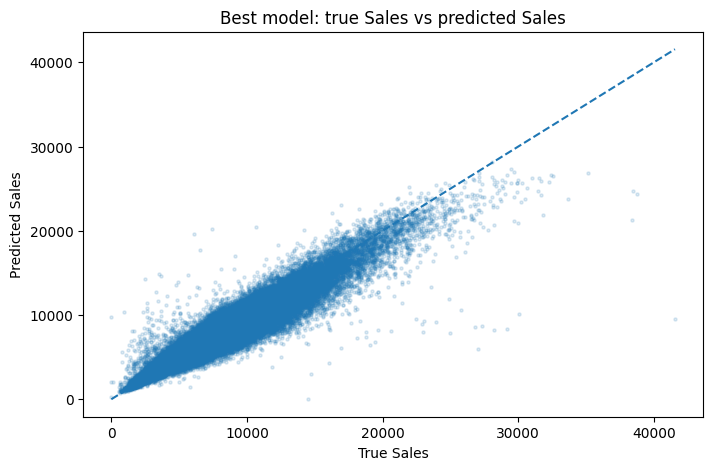

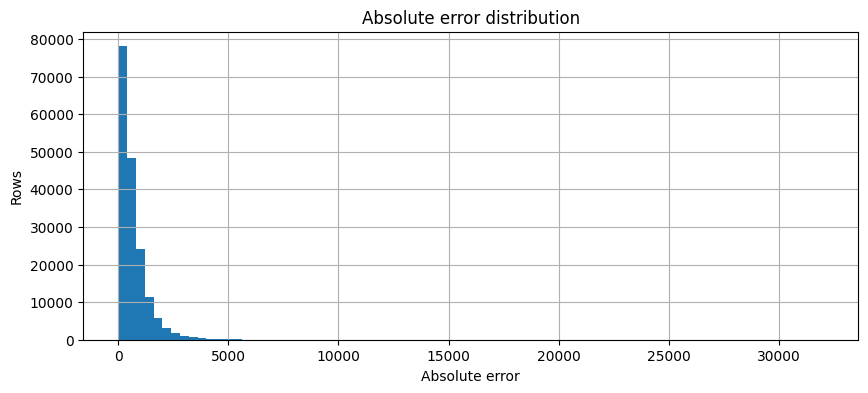

In [35]:
# Переводим y_true и y_pred из log1p(Sales) обратно в Sales
y_val_sales = np.expm1(y_val)
best_val_pred_sales = np.expm1(best_gb_val_pred)

# На всякий случай убираем отрицательные предсказания
best_val_pred_sales = np.clip(best_val_pred_sales, 0, None)

# Считаем ошибки в исходной шкале Sales
errors = pd.DataFrame(
    {
        "y_true": y_val_sales,
        "y_pred": best_val_pred_sales,
    }
)

errors["abs_error"] = np.abs(errors["y_true"] - errors["y_pred"])
errors["pct_error"] = errors["abs_error"] / errors["y_true"].replace(0, np.nan)

display(
    errors.describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

# True vs predicted Sales
plt.figure(figsize=(8, 5))
plt.scatter(errors["y_true"], errors["y_pred"], alpha=0.15, s=5)
plt.plot(
    [errors["y_true"].min(), errors["y_true"].max()],
    [errors["y_true"].min(), errors["y_true"].max()],
    linestyle="--"
)
plt.title("Best model: true Sales vs predicted Sales")
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.show()

# Распределение абсолютной ошибки
plt.figure(figsize=(10, 4))
errors["abs_error"].hist(bins=80)
plt.title("Absolute error distribution")
plt.xlabel("Absolute error")
plt.ylabel("Rows")
plt.show()

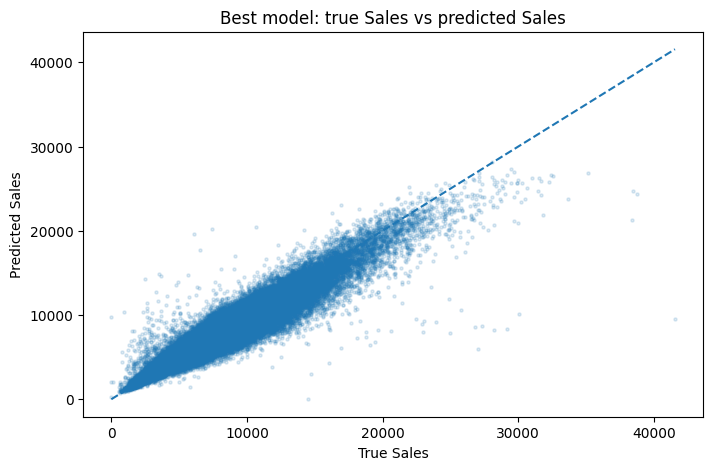

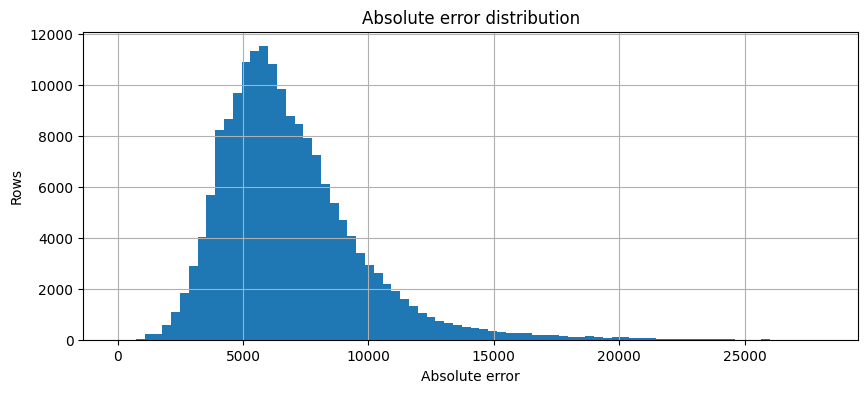

In [ ]:
y_val_sales = np.expm1(y_val)
best_val_pred_sales = np.expm1(best_gb_val_pred)
best_val_pred_sales = np.clip(best_val_pred_sales, 0, None)

plt.figure(figsize=(8, 5))
plt.scatter(y_val_sales, best_val_pred_sales, alpha=0.15, s=5)
plt.plot(
    [y_val_sales.min(), y_val_sales.max()],
    [y_val_sales.min(), y_val_sales.max()],
    linestyle="--"
)
plt.title("Best model: true Sales vs predicted Sales")
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.show()

Таблица ошибок

- Средние фактические продажи на validation составляют около **7123**, средний прогноз модели — около **6871**, то есть модель в среднем немного занижает продажи.
- Медианные значения также близки: `y_true` около **6560**, `y_pred` около **6351**.
- Средняя относительная ошибка `pct_error` составляет около **9.2%**, медианная — около **7.3%**, что выглядит достаточно хорошо для baseline/первой бустинговой модели.
- 95% наблюдений имеют относительную ошибку ниже **23.2%**, а 99% — ниже **34.8%**.
- Максимальная относительная ошибка очень высокая, но это единичные случаи, вероятно связанные с очень малыми или нулевыми фактическими продажами, где относительная ошибка становится нестабильной.

График True Sales vs Predicted Sales

- Основная масса точек лежит близко к диагонали, значит модель хорошо улавливает общий уровень продаж.
- Для средних значений продаж модель работает наиболее стабильно: плотное облако точек расположено вдоль линии идеального прогноза.
- На очень высоких продажах заметен больший разброс и склонность модели недооценивать пики: при `True Sales` выше 25–30 тысяч предсказания часто ниже фактических значений.
- Это ожидаемо, потому что экстремально высокие продажи редкие, а модель, обученная на `log1p(Sales)`, сглаживает влияние таких выбросов.

График распределения абсолютной ошибки

- Распределение абсолютной ошибки сильно скошено вправо: большинство ошибок небольшие, но есть редкие крупные промахи.
- Медианная абсолютная ошибка составляет около **461**, средняя — около **652**. Средняя выше медианы из-за правого хвоста крупных ошибок.
- У 75% наблюдений абсолютная ошибка ниже **861**, у 90% — ниже **1423**, у 95% — ниже **1893**.
- Крупные ошибки в хвосте, вплоть до **32008**, связаны с редкими экстремальными случаями, где модель не смогла точно предсказать очень высокие продажи или аномальные дни.


## Общий вывод

- Модель `HistGradientBoosting tuned` хорошо предсказывает основную массу продаж и значительно превосходит простые baseline-модели.
- Основная проблема модели — недооценка редких экстремально высоких продаж.
- Для дальнейшего улучшения можно добавить более сильные store-level признаки, признаки промо-периодов, календарные события, а также отдельно анализировать дни с самыми крупными ошибками.